# Naive Oracle Block Encoding for Linear Pendulum

This notebook studies a matrix-entry oracle construction of a block encoding and applies it to the forward-Euler update of the linear pendulum.

In the previous manual block-encoding notebook, the full unitary dilation was constructed explicitly:

\begin{equation}
U =
\begin{pmatrix}
A/\alpha & * \\
* & * \end{pmatrix}.
\end{equation}

That construction is useful for understanding block encoding, but it requires building the full enlarged unitary matrix. Here we use a different approach: instead of constructing the full unitary dilation directly, we encode the entries of the matrix using controlled $R_y$ rotations.

For an $N\times N$ real matrix $A$, the naive oracle construction produces a block encoding of
$
\frac{A}{N}.
$

If the matrix is first scaled as
$
B=\frac{A}{\alpha},
$
then the encoded block is

$$
\frac{B}{N}=\frac{A}{\alpha N}.
$$

For the $2\times2$ linear pendulum update matrix, $N=2$, so the successful branch contains

$$
\frac{M|\psi\rangle}{2\alpha}.
$$

The purpose of this notebook is to:

1. construct a naive matrix-entry oracle using multi-controlled $R_y$ rotations,
2. verify that the extracted block is $A/N$,
3. apply the construction to the linear pendulum Euler update matrix,
4. use statevector extraction to recover the time-stepping update,
5. prepare the ground for the optimized FABLE construction.

This notebook focuses on exact statevector extraction. Measurement/QST readout is not repeated here because the readout behavior was already studied in the LCU and manual block-encoding notebooks.

## Relation to FABLE

The construction in this notebook is not yet the optimized FABLE circuit. It is the direct or naive version of the matrix-entry oracle.

The oracle loads each matrix entry $B_{ij}$ into the amplitude of an ancilla qubit using a controlled $R_y$ rotation:

$$
|0\rangle_a |i\rangle |j\rangle
\mapsto
\left(
B_{ij}|0\rangle_a+
\sqrt{1-B_{ij}^2}|1\rangle_a
\right)
|i\rangle |j\rangle.
$$

The naive implementation uses one multi-controlled rotation for each matrix entry. This is correct, but inefficient.

The FABLE method keeps the same block-encoding idea, but replaces the multi-controlled rotations with a more efficient multiplexed-rotation circuit built from transformed angles and a Gray-code CNOT ladder. Therefore, this notebook should be viewed as the conceptual bridge between manual block encoding and FABLE.

## Imports

We use Qiskit to build the naive oracle circuit and `Statevector`/`Operator` to verify the encoded block. The implementation here is exact statevector simulation, not a measurement-based run.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, Operator
from qiskit.circuit.library import RYGate

## Qubit Convention

For a $2\times2$ matrix, we use three qubits:

$$
q_0 = \text{entry-loading ancilla } a,
$$

$$
q_1 = \text{row/summation register},
$$

$$
q_2 = \text{column/input register}.
$$

The initial state has the form

$$
|0\rangle_a |0\rangle_{\text{row}} |\psi\rangle_{\text{col}}.
$$

The row register is placed in a superposition using a Hadamard gate. The matrix-entry oracle then loads the entries $B_{ij}$. After a SWAP and a second Hadamard, the successful branch is obtained by post-selecting

$$
q_0=0,\qquad q_1=0.
$$

The remaining qubit $q_2$ carries the output state.

Qiskit uses little-endian statevector ordering. For three qubits, the computational basis is ordered as

$$
|q_2 q_1 q_0\rangle.
$$

Therefore, the basis index is

$$
\text{index}=q_0+2q_1+4q_2.
$$

In [2]:
def basis_index(q0, q1, q2):
    return q0 + 2*q1 + 4*q2

## Scaling matrix entries

The entry-loading oracle uses the relation

$$
R_y(2\theta_{ij})|0\rangle
= \cos(\theta_{ij})|0\rangle+\sin(\theta_{ij})|1\rangle.
$$

To encode a matrix entry $B_{ij}$ into the amplitude of $|0\rangle_a$, we choose

$$
\theta_{ij}=\arccos(B_{ij}).
$$

This requires

$$
|B_{ij}|\leq 1
$$

for all entries. Therefore, before constructing the oracle, we scale the matrix as

$$
B=\frac{A}{\alpha},
$$

where \(\alpha\) is chosen so that all entries of $B$ lie in $[-1,1]$.

In this notebook, for the naive entry oracle, $\alpha$ is chosen based on the largest absolute matrix entry. This is different from manual block encoding, where $\alpha$ was chosen based on the spectral norm. The reason is that the naive oracle encodes individual entries through $\arccos(B_{ij})$, so the entry-wise bound is the relevant condition.

In [3]:
def scale_matrix_entries(A, alpha=None, alpha_padding=1.001):
    #Actual matrix
    A = np.array(A, dtype=float)
    #Setting alpha value based on max. value of the components of A
    max_abs_entry = np.max(np.abs(A))

    if max_abs_entry == 0:
        alpha = 1.0 if alpha is None else alpha
        return A / alpha, alpha

    if alpha is None:
        alpha = alpha_padding * max_abs_entry

    if alpha < max_abs_entry - 1e-12:
        raise ValueError("alpha must be at least max(abs(A_ij)).")
    #Defining B matrix which is used to create the unitary matrix
    B = A / alpha

    if np.max(np.abs(B)) > 1 + 1e-12:
        raise ValueError("Scaled matrix has entries outside [-1, 1].")

    return B, alpha

## Controlled rotation for a selected bitstring

Qiskit multi-controlled gates are naturally activated when all control qubits are in the state $|1\rangle$. However, for the matrix-entry oracle we need rotations controlled on arbitrary bitstrings.

For example, to apply a rotation only when the controls are $|01\rangle$, we temporarily flip the qubits that should be $0$, apply the controlled gate, and then undo the flips.

This helper function implements that logic.

In [4]:
def apply_controlled_ry_for_bitstring(qc, controls, target, bitstring, angle):
    #Since the qiskit controls applies only when qubit is 1, so we flip the bit when controls involves qubit being 0
    # Convert desired 0 controls into 1 controls using X gates.
    for qubit, bit in zip(controls, bitstring):
        if bit == 0:
            qc.x(qubit)
    #Applying RY gate based on controls
    controlled_ry = RYGate(angle).control(len(controls))
    qc.append(controlled_ry, controls + [target])

    # Undo X gates.
    for qubit, bit in zip(controls, bitstring):
        if bit == 0:
            qc.x(qubit)

## Naive entry loading oracle of $2\times 2$ matrix

For a scaled matrix

$$
B=
\begin{pmatrix}
B_{00} & B_{01}\\
B_{10} & B_{11}
\end{pmatrix},
$$

the oracle should perform

$$
|0\rangle_a |i\rangle |j\rangle
\mapsto
\left(
B_{ij}|0\rangle_a+
\sqrt{1-B_{ij}^2}|1\rangle_a
\right)
|i\rangle |j\rangle.
$$

For each entry $B_{ij}$, we define

$$
\theta_{ij}=\arccos(B_{ij}).
$$

Then,

$$
R_y(2\theta_{ij})|0\rangle
=  B_{ij}|0\rangle+
\sqrt{1-B_{ij}^2}|1\rangle.
$$

The naive implementation applies one controlled $R_y(2\theta_{ij})$ rotation for each matrix entry. Since the $2\times2$ case has four entries, this requires four controlled rotations.

This implementation is correct but inefficient. The optimized FABLE method later replaces this set of multi-controlled rotations with a multiplexed-rotation circuit using transformed angles and CNOTs.

In [5]:
def apply_naive_entry_oracle_2x2(qc, B, ancilla=0, row=1, col=2):
    #B matrix
    B = np.array(B, dtype=float)

    if B.shape != (2, 2):
        raise ValueError("This function currently supports only 2x2 matrices.")

    if np.max(np.abs(B)) > 1 + 1e-12:
        raise ValueError("All entries of B must be in [-1, 1].")

    #controls are row  and column of matrix
    controls = [row, col]

    for i in [0, 1]:
        for j in [0, 1]:
            #defining value based on matrix component
            value = np.clip(B[i, j], -1.0, 1.0)
            theta = np.arccos(value)
            #angle used in RY gate should be multiplied wth 2
            angle = 2 * theta

            #Apply multicontrolled RY gate based on controls and target
            apply_controlled_ry_for_bitstring(
                qc,
                controls=controls,
                target=ancilla,
                bitstring=[i, j],
                angle=angle
            )

## Full Naive Oracle Block-encoding circuit

The entry oracle alone only loads matrix entries $B_{ij}$. It does not yet apply the matrix $B$ to a state. To turn entry loading into a block encoding, we use the following structure:

1. Apply a Hadamard gate to the row register.
2. Apply the matrix-entry oracle.
3. Swap the row and column registers.
4. Apply another Hadamard gate to the row register.
5. Extract the branch where the entry ancilla and row/summation register are both zero.

For a $2\times2$ matrix, this construction block-encodes

$$
\frac{B}{2}.
$$

The first Hadamard creates a superposition over row indices. The oracle attaches the corresponding matrix entry $B_{ij}$. The SWAP places the output row index into the remaining system register. The second Hadamard and post-selection perform the summation over the original input index.

Thus, for an input state

$$
|\psi\rangle=\sum_j \psi_j |j\rangle,
$$

the successful branch contains

$$
\frac{B|\psi\rangle}{2}.
$$

In [6]:
def create_naive_oracle_block_encoding_circuit_2x2(B):
    #Defining ancilla and controls
    ancilla = 0
    row = 1
    col = 2

    #Creating quantum circuit
    qc = QuantumCircuit(3)

    # First Hadamard: create superposition over row index i.
    qc.h(row)

    # Entry-loading oracle: multicontrolled RY gates
    apply_naive_entry_oracle_2x2(qc, B, ancilla=ancilla, row=row, col=col)

    # Swap row and column registers.
    # After this, q2 carries the output row index.
    qc.swap(row, col)

    # Second Hadamard: sum over the old input index.
    qc.h(row)

    return qc

##  Extract the encoded block

To verify the circuit, we extract the block corresponding to the successful branch

$$
q_0=0,\qquad q_1=0.
$$

The remaining qubit $q_2$ is the system/output register.

The block element is

$$
\left[U_{\mathrm{block}}\right]_{i,j}
=\langle q_0=0,q_1=0,q_2=i|
U
|q_0=0,q_1=0,q_2=j\rangle.
$$

For a correct naive-oracle block encoding of a $2\times2$ matrix $B$, this extracted block should be

$$
\frac{B}{2}.
$$

In [7]:
def extract_encoded_block_2x2(qc):
    
    U = Operator(qc).data

    block = np.zeros((2, 2), dtype=complex)

    for out_bit in [0, 1]:
        for in_bit in [0, 1]:
            out_index = basis_index(q0=0, q1=0, q2=out_bit)
            in_index = basis_index(q0=0, q1=0, q2=in_bit)

            block[out_bit, in_bit] = U[out_index, in_index]

    return block

## Testing the code for a simple matrix

Before applying the circuit to the pendulum update matrix, we first test it on a small matrix with entries already in $[-1,1]$:

$$
A=
\begin{pmatrix}
0.6 & 0.2\\
-0.3 & 0.8
\end{pmatrix}.
$$

Since this is a $2\times2$ matrix, the expected encoded block is

$$
\frac{A}{2}.
$$

This test verifies the qubit ordering, controlled-rotation logic, SWAP placement, and block extraction convention.

In [8]:
#test matrix
A_test = np.array([
    [0.6, 0.2],
    [-0.3, 0.8]
], dtype=float)

#B matrix obtained from A matrix
B_test, alpha_test = scale_matrix_entries(A_test, alpha=1.0)

#Creating quantum circuit to obtain the block encoded matrix
qc_test = create_naive_oracle_block_encoding_circuit_2x2(B_test)

#obtaining matrix block from the bigger encoded matrix 
encoded_block = extract_encoded_block_2x2(qc_test)

print("Input matrix A:")
print(A_test)

print("\nEncoded block:")
print(np.real_if_close(encoded_block))

print("\nExpected block A/2:")
print(A_test / 2)

print("\nBlock-encoding error:")
print(np.linalg.norm(encoded_block - A_test / 2))

Input matrix A:
[[ 0.6  0.2]
 [-0.3  0.8]]

Encoded block:
[[ 0.3   0.1 ]
 [-0.15  0.4 ]]

Expected block A/2:
[[ 0.3   0.1 ]
 [-0.15  0.4 ]]

Block-encoding error:
1.7826341206873999e-16


The extracted block agrees with $A/2$ up to numerical precision. This confirms that the naive entry oracle and the Hadamard/SWAP/Hadamard structure are producing the intended block encoding.

## Linear pendulum update matrix and classical solution

The linearized pendulum equation is

$$
\frac{d^2x}{dt^2}+\omega^2x=0.
$$

Introducing the velocity variable

$$
y=\frac{dx}{dt},
$$

the second-order equation can be written as the first-order system

$$
\frac{dx}{dt}=y,
\qquad
\frac{dy}{dt}=-\omega^2x.
$$

Using the forward-Euler method with time step $h$,

$$
x_{n+1}=x_n+h y_n,
$$

$$
y_{n+1}=y_n-h\omega^2x_n.
$$

Therefore, the update can be written in matrix form as

$$
u_{n+1}=M u_n,
$$

where

$$
u_n=
\begin{pmatrix}
x_n\\
y_n
\end{pmatrix},
\qquad
M=
\begin{pmatrix}
1 & h\\
-h\omega^2 & 1
\end{pmatrix}.
$$

The function `pendulum_update_matrix` constructs $M$, while
`classical_euler_linear_pendulum` applies the same matrix update
classically over multiple time steps. The classical Euler result will
serve as the reference for verifying the naive-oracle implementation.

It is important to distinguish this reference solution from the exact
continuous solution of the pendulum equation. Both the classical and
quantum procedures implemented here use the same forward-Euler
discretization. Therefore, agreement between them verifies the
block-encoding implementation, but it does not remove the discretization
error of the Euler method.

In [9]:
def pendulum_update_matrix(h, omega):
    return np.array([
        [1.0, h],
        [-h * omega**2, 1.0]
    ], dtype=float)


def classical_euler_linear_pendulum(h, omega, x0, y0, n_steps):
    x_vals = [x0]
    y_vals = [y0]

    x, y = x0, y0

    for _ in range(n_steps):
        x_next = x + h * y
        y_next = y - h * omega**2 * x

        x, y = x_next, y_next

        x_vals.append(x)
        y_vals.append(y)

    t_vals = np.arange(n_steps + 1) * h
    return t_vals, np.array(x_vals), np.array(y_vals)

## Verifying the block encoding of linear pendulum

The pendulum update matrix contains diagonal entries equal to $1$.
To ensure that every entry supplied to the rotation oracle lies strictly
inside the interval $[-1,1]$, we scale the matrix as

$$
B=\frac{M}{\alpha},
$$

with

$$
\alpha=1.001\max_{i,j}|M_{ij}|.
$$

For the parameters used below, the largest absolute entry of $M$ is
$1$, giving $\alpha=1.001$.

Because the matrix dimension is $N=2$, the circuit should encode

$$
\frac{B}{2}
=\frac{M}{2\alpha}.
$$

We construct the full three-qubit unitary, extract the submatrix
corresponding to

$$
q_0=0,\qquad q_1=0,
$$

and compare it directly with $M/(2\alpha)$. A block-encoding error near
machine precision confirms that the controlled rotations, SWAP,
Hadamard gates, and qubit-ordering convention are all consistent.

In [10]:
h = 0.001
omega = 1.0

M = pendulum_update_matrix(h, omega)
B, alpha = scale_matrix_entries(M)

qc_pendulum = create_naive_oracle_block_encoding_circuit_2x2(B)

encoded_block = extract_encoded_block_2x2(qc_pendulum)
expected_block = B / 2

print("alpha =", alpha)

print("\nM:")
print(M)

print("\nB = M / alpha:")
print(B)

print("\nEncoded block:")
print(np.real_if_close(encoded_block))

print("\nExpected block B/2 = M/(2 alpha):")
print(expected_block)

print("\nBlock-encoding error:")
print(np.linalg.norm(encoded_block - expected_block))

alpha = 1.001

M:
[[ 1.     0.001]
 [-0.001  1.   ]]

B = M / alpha:
[[ 0.999001  0.000999]
 [-0.000999  0.999001]]

Encoded block:
[[ 4.995005e-01  4.995005e-04]
 [-4.995005e-04  4.995005e-01]]

Expected block B/2 = M/(2 alpha):
[[ 0.4995005  0.0004995]
 [-0.0004995  0.4995005]]

Block-encoding error:
3.9741986335795514e-16


## One step statevector extraction

At time step $n$, the classical pendulum state is

$$
u_n=
\begin{pmatrix}
x_n\\
y_n
\end{pmatrix}.
$$

Since a quantum state must be normalized, we prepare

$$
|\psi_n\rangle
=\frac{u_n}{\|u_n\|}
=\frac{x_n}{\|u_n\|}|0\rangle
+
\frac{y_n}{\|u_n\|}|1\rangle,
$$

where

$$
\|u_n\|=\sqrt{x_n^2+y_n^2}.
$$

For a real two-component vector, this state can be prepared using a single
$R_y$ rotation. Since

$$
R_y(\theta)|0\rangle
=\cos\left(\frac{\theta}{2}\right)|0\rangle
+
\sin\left(\frac{\theta}{2}\right)|1\rangle,
$$

we choose

$$
\theta
=2\tan^{-1}(y_n/x_n).
$$

This gives

$$
\cos\left(\frac{\theta}{2}\right)
=\frac{x_n}{\|u_n\|},
\qquad
\sin\left(\frac{\theta}{2}\right)
=\frac{y_n}{\|u_n\|}.
$$

The normalized state $|\psi_n\rangle$ is prepared on the system qubit
$q_2$. The entry ancilla $q_0$ and row register $q_1$ are initialized
in $|0\rangle$, so the complete input state is

$$
|0\rangle_{q_0}|0\rangle_{q_1}|\psi_n\rangle_{q_2}.
$$

The naive-oracle block-encoding circuit is then applied to this state.

Create the full naive-oracle block-encoding circuit for one pendulum step.

    Qubits:
        q0 = entry ancilla
        q1 = row/summation register
        q2 = system/input register

    The system state is prepared on q2.

In [11]:
def create_naive_oracle_pendulum_circuit(x, y, h, omega, alpha=None):
    #Defining qubit labels
    ancilla = 0
    row = 1
    system = 2

    #present state vector, u_n
    u = np.array([x, y], dtype=float)
    norm_u = np.linalg.norm(u)

    if norm_u == 0:
        raise ValueError("Cannot encode the zero vector as a quantum state.")

    #Angle to create quantum state corresponding to u_n
    theta = 2 * np.arctan2(y, x)

    #Pendulum matrix
    M = pendulum_update_matrix(h, omega)
    #converting the matrix entries
    B, alpha = scale_matrix_entries(M, alpha=alpha)

    #Creating quantum circuit
    qc = QuantumCircuit(3)

    # Prepare |psi> on the system/input register q2.
    qc.ry(theta, system)

    # Add the naive-oracle block-encoding circuit.
    block_qc = create_naive_oracle_block_encoding_circuit_2x2(B)
    qc.compose(block_qc, inplace=True)

    return qc, alpha, norm_u

## Obtaining solution $u_{n+1}$ using Statevector simulation

Let $U_B$ denote the naive-oracle block-encoding unitary constructed
from

$$
B=\frac{M}{\alpha}.
$$

The upper-left block of this unitary is

$$
\frac{B}{2}
=\frac{M}{2\alpha}.
$$

Therefore, applying $U_B$ to the input state produces a state of the
form

$$
U_B
\left(
|0\rangle_{q_0}|0\rangle_{q_1}|\psi_n\rangle_{q_2}
\right)
=|0\rangle_{q_0}|0\rangle_{q_1}
\frac{M|\psi_n\rangle}{2\alpha}
+
|\Phi^\perp\rangle,
$$

where $|\Phi^\perp\rangle$ contains all branches for which at least one
of the qubits $q_0$ or $q_1$ is not zero.

Post-selecting the successful branch

$$
q_0=0,\qquad q_1=0
$$

leaves the unnormalized output

$$
|\widetilde{\psi}_{n+1}\rangle
=\frac{M|\psi_n\rangle}{2\alpha}.
$$

Because

$$
|\psi_n\rangle=\frac{u_n}{\|u_n\|},
$$

the extracted branch can also be written as

$$
|\widetilde{\psi}_{n+1}\rangle
=\frac{M u_n}{2\alpha\|u_n\|}
=\frac{u_{n+1}}{2\alpha\|u_n\|}.
$$

The unnormalized classical update vector is consequently recovered as

$$
u_{n+1}
=2\alpha\|u_n\|
|\widetilde{\psi}_{n+1}\rangle.
$$

This explains the rescaling factor used in
`naive_oracle_step_statevector`.

The probability of observing the successful branch is

$$
p_{\mathrm{succ}}
=\left\|
\frac{M|\psi_n\rangle}{2\alpha}
\right\|^2
=\frac{\|M|\psi_n\rangle\|^2}{4\alpha^2}.
$$

Equivalently,

$$
p_{\mathrm{succ}}
=\frac{\|u_{n+1}\|^2}
{4\alpha^2\|u_n\|^2}.
$$

Thus, the factor $1/(2\alpha)$ affects both the extracted amplitudes
and the probability of successful post-selection.

In this notebook, the successful amplitudes are read directly from the
exact statevector. This provides a clean verification of the
block-encoding circuit. On quantum hardware, these amplitudes would
not be directly available and would have to be reconstructed through
measurements, tomography, or an observable-based readout procedure.

In [12]:
def naive_oracle_step_statevector(x, y, h, omega, alpha=None):

    #create naive oracle for one time step
    qc, alpha, norm_u = create_naive_oracle_pendulum_circuit(
        x, y, h, omega, alpha=alpha
    )

    #obtaining state using Statevector
    state = Statevector.from_instruction(qc).data

    # Success condition:
    # q0 = 0, q1 = 0.
    # Remaining q2 gives output amplitudes.
    success_branch = np.array([
        state[basis_index(q0=0, q1=0, q2=0)],
        state[basis_index(q0=0, q1=0, q2=1)]])

    # success_branch = M |psi> / (2 alpha)
    # recover u_next = M u
    u_next = 2 * alpha * norm_u * success_branch

    x_next = np.real_if_close(u_next[0]).real
    y_next = np.real_if_close(u_next[1]).real

    return x_next, y_next

## One time step test

We first test a single Euler step using

$$
h=0.001,\qquad \omega=1,
$$

with the initial condition

$$
u_0=
\begin{pmatrix}
1\\
0
\end{pmatrix}.
$$

The classical forward-Euler update is

$$
x_1=x_0+h y_0=1,
$$

and

$$
y_1=y_0-h\omega^2x_0=-0.001.
$$

The same initial vector is normalized and prepared on the system qubit,
after which the naive-oracle block-encoding circuit is applied. The
successful statevector branch is extracted and multiplied by

$$
2\alpha\|u_0\|
$$

to recover the unnormalized output vector.

The naive-oracle result agrees with the direct classical Euler update
up to floating-point precision. This verifies the complete one-step
procedure:

1. normalization of the input vector,
2. quantum-state preparation,
3. application of the block-encoding circuit,
4. extraction of the successful branch, and
5. recovery of the unnormalized classical vector.

The small nonzero error reported below is numerical round-off error
from the statevector simulation rather than an approximation introduced
by the block encoding.

In [13]:
h = 0.001
omega = 1.0

x0 = 1.0
y0 = 0.0

x_classical_1 = x0 + h * y0
y_classical_1 = y0 - h * omega**2 * x0

x_naive_1, y_naive_1 = naive_oracle_step_statevector(
    x0, y0, h, omega
)

print("Classical one step:")
print(x_classical_1, y_classical_1)

print("\nNaive-oracle block encoding one step:")
print(x_naive_1, y_naive_1)

print("\nOne-step error:")
print(np.sqrt((x_naive_1 - x_classical_1)**2 + (y_naive_1 - y_classical_1)**2))

Classical one step:
1.0 -0.001

Naive-oracle block encoding one step:
0.9999999999999996 -0.0010000000000001186

One-step error:
4.596563562857152e-16


## Full trajectory using Naive oracle

To construct a complete trajectory, the one-step procedure is repeated
iteratively. At every time step, the extracted vector

$$
u_{n+1}=M u_n
$$

becomes the input for the next step.

The numerical procedure is therefore

$$
u_n
\longrightarrow
|\psi_n\rangle
=\frac{u_n}{\|u_n\|}
\longrightarrow
\frac{M|\psi_n\rangle}{2\alpha}
\longrightarrow
u_{n+1}.
$$

The last operation represents statevector extraction followed by
classical rescaling with $2\alpha\|u_n\|$.

The function `naive_oracle_trajectory_statevector` repeats this process
for the requested number of time steps and stores the recovered values
of $x_n$ and $y_n$.

It is important to note that this implementation is a hybrid iterative
demonstration. After each circuit execution, the output amplitudes are
extracted classically and used to construct the input state for the next
circuit. Therefore, the notebook does not apply the block-encoding
unitary repeatedly to a single quantum state without intermediate
readout.

This classical extraction is useful for verifying that the encoded
matrix reproduces the Euler update at every step. However, on quantum
hardware, repeatedly reconstructing and re-preparing the full state
would introduce a significant readout and state-preparation cost.

In [14]:
def naive_oracle_trajectory_statevector(h, omega, x0, y0, n_steps, alpha=None):
    x_vals = [x0]
    y_vals = [y0]

    x, y = x0, y0

    for _ in range(n_steps):
        x, y = naive_oracle_step_statevector(
            x, y, h, omega, alpha=alpha
        )

        x_vals.append(x)
        y_vals.append(y)

    t_vals = np.arange(n_steps + 1) * h

    return t_vals, np.array(x_vals), np.array(y_vals)

## Running full trajectory and plots

We now compare the naive-oracle trajectory with the direct classical
Euler trajectory using

$$
h=0.001,\qquad
\omega=\sqrt{9.8},
$$

and the initial condition

$$
x_0=\frac{\pi}{2},
\qquad
y_0=1.
$$

The evolution is performed for $10,000$ Euler steps, corresponding to
a total simulated time

$$
t_{\mathrm{final}}=n_{\mathrm{steps}}h=10.
$$

Both calculations use the same update matrix

$$
M=
\begin{pmatrix}
1 & h\\
-h\omega^2 & 1
\end{pmatrix}.
$$

Consequently, any difference between the two trajectories measures the
numerical error of the block-encoding implementation and repeated
statevector extraction. It does not measure the forward-Euler
discretization error relative to the exact continuous pendulum
solution.

In [15]:
h = 0.001
omega = np.sqrt(9.8)
x0 = np.pi/2
y0 = 1.0
n_steps = 10000

t_cl, x_cl, y_cl = classical_euler_linear_pendulum(
    h, omega, x0, y0, n_steps
)

t_naive, x_naive, y_naive = naive_oracle_trajectory_statevector(
    h, omega, x0, y0, n_steps
)

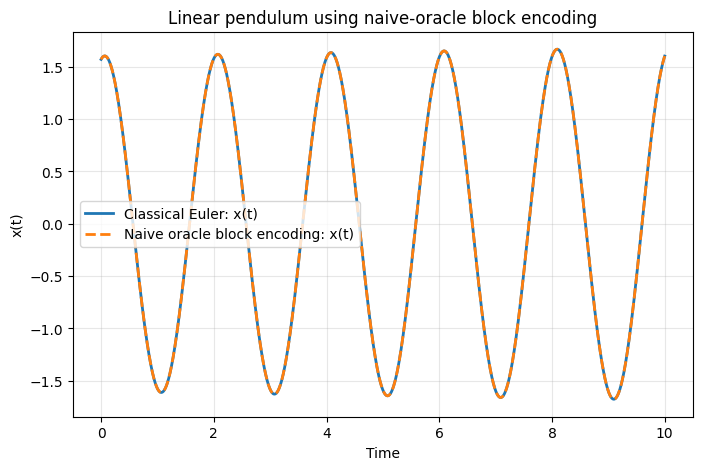

In [16]:
#x(t) plot
plt.figure(figsize=(8, 5))
plt.plot(t_cl, x_cl, label="Classical Euler: x(t)", linewidth=2)
plt.plot(t_naive, x_naive, "--", label="Naive oracle block encoding: x(t)", linewidth=2)
plt.xlabel("Time")
plt.ylabel("x(t)")
plt.title("Linear pendulum using naive-oracle block encoding")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

The position trajectories obtained from the direct Euler update and the
naive-oracle block encoding overlap across the full simulation interval.
This shows that the block-encoding circuit reproduces the action of the
Euler update matrix on the position component.

The amplitude of the plotted Euler trajectory changes slightly over
time because forward Euler does not exactly conserve the energy of the
harmonic oscillator. Since the same effect appears in both curves, it
is a property of the chosen discretization rather than an error caused
by the block encoding.

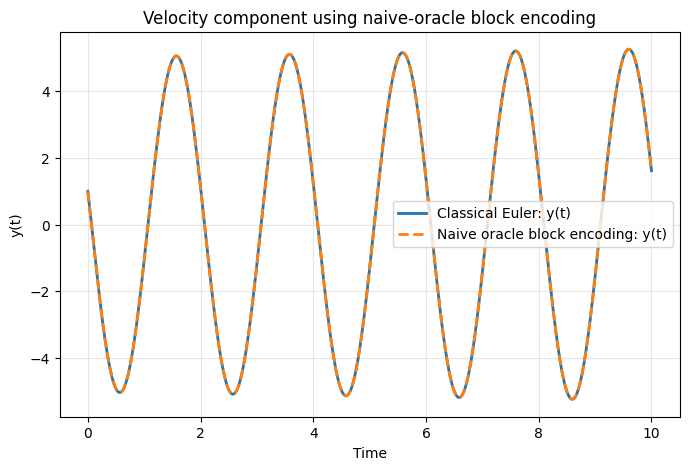

In [17]:
#y(t) plot
plt.figure(figsize=(8, 5))
plt.plot(t_cl, y_cl, label="Classical Euler: y(t)", linewidth=2)
plt.plot(t_naive, y_naive, "--", label="Naive oracle block encoding: y(t)", linewidth=2)
plt.xlabel("Time")
plt.ylabel("y(t)")
plt.title("Velocity component using naive-oracle block encoding")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

The velocity components also agree across the complete trajectory.
Together, the $x(t)$ and $y(t)$ comparisons confirm that the
naive-oracle circuit reproduces both components of

$$
u_{n+1}=M u_n
$$

at every time step.

As with the position trajectory, any long-time drift associated with the
forward-Euler method is shared by the classical and naive-oracle
solutions. The relevant test here is whether the encoded matrix
reproduces the same discrete update, rather than whether forward Euler
exactly reproduces the continuous pendulum dynamics.

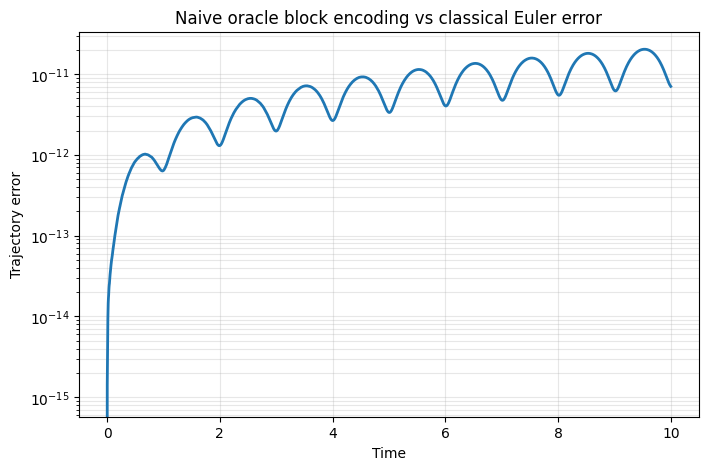

Maximum trajectory error: 2.038367215515175e-11


In [18]:
#Error plot
trajectory_error = np.sqrt((x_naive - x_cl)**2 + (y_naive - y_cl)**2)

plt.figure(figsize=(8, 5))
plt.plot(t_cl, trajectory_error, linewidth=2)
plt.yscale("log")
plt.xlabel("Time")
plt.ylabel("Trajectory error")
plt.title("Naive oracle block encoding vs classical Euler error")
plt.grid(True, which="both", alpha=0.3)
plt.show()

print("Maximum trajectory error:", np.max(trajectory_error))

The trajectory error is calculated as the Euclidean distance between
the classical and naive-oracle results:

$$
\epsilon_n
=\left\|
u_n^{(\mathrm{naive})}
-u_n^{(\mathrm{classical})}
\right\|_2.
$$

Explicitly,

$$
\epsilon_n
=\sqrt{
\left(x_n^{(\mathrm{naive})}-x_n^{(\mathrm{classical})}\right)^2
+
\left(y_n^{(\mathrm{naive})}-y_n^{(\mathrm{classical})}\right)^2
}.
$$

The error remains close to numerical precision, although it gradually
accumulates over the $10,000$ repeated updates. This accumulation
comes from floating-point operations involved in circuit construction,
statevector simulation, amplitude extraction, and rescaling at every
time step.

The maximum error remains extremely small compared with the scale of the
trajectory. The result therefore confirms that, within numerical
precision, the naive-oracle circuit implements the same matrix update as
the direct classical Euler calculation.

## Computational cost of the naive oracle

For an $N\times N$ matrix, the naive entry oracle applies one
multi-controlled rotation for every matrix entry. It therefore requires
$
N^2
$

controlled $R_y$ rotations.
If
$
N=2^n,
$
the row and column indices each require $n$ qubits. Every entry rotation
is then controlled by $2n$ index qubits. The naive circuit consequently
has the following structure:

- one entry-loading ancilla,
- $n$ row-register qubits,
- $n$ column-register qubits, and
- $N^2=4^n$ multi-controlled rotations.

The total number of logical qubits is therefore
$
2n+1.
$

Although the qubit count grows only logarithmically with the matrix
dimension, the number of explicitly specified entry rotations grows as
$
O(N^2).
$

Furthermore, decomposing each multi-controlled rotation into elementary
one- and two-qubit gates introduces additional circuit depth.

For the $2\times2$ example in this notebook, only four controlled
rotations are required, so the direct construction is easy to inspect.
For larger matrices, however, this approach quickly becomes
impractical.

The naive oracle should therefore be viewed mainly as a transparent
implementation of the matrix-entry block-encoding principle. It shows
how matrix elements become ancilla amplitudes and how the
Hadamard--oracle--SWAP--Hadamard structure produces the block $A/N$.
Its main limitation is the inefficient implementation of the entry
oracle.

## Conclusion

In this notebook, we constructed a naive matrix-entry block encoding and
applied it to the forward-Euler update matrix of the linear pendulum.

For a real $N\times N$ matrix $A$, the entries were first scaled as

$$
B=\frac{A}{\alpha},
\qquad
{\rm so \ that} \qquad
|B_{ij}|\leq 1.
$$

Each matrix entry was then loaded into the $|0\rangle$ amplitude of an
ancilla qubit using

$$
R_y\!\left(2\arccos B_{ij}\right).
$$

Combining this entry oracle with the
Hadamard--oracle--SWAP--Hadamard structure produced the encoded block

$$
\frac{B}{N}
=\frac{A}{\alpha N}.
$$

For the $2\times2$ pendulum update matrix, the extracted block was

$$
\frac{M}{2\alpha}.
$$

The circuit was verified in three stages:

1. extraction of the encoded block for a simple test matrix,
2. comparison of a single pendulum update with the classical Euler
   calculation, and
3. comparison of the full statevector-based trajectory with the
   classical Euler trajectory.

In each case, the circuit reproduced the expected result up to numerical
precision.

This construction makes the matrix-entry mechanism more explicit than
the manual unitary-dilation approach. However, it requires one
multi-controlled rotation for every matrix element. The resulting
$O(N^2)$ entry-loading structure and the cost of decomposing
multi-controlled rotations make it unsuitable as an optimized
implementation for larger matrices.

The next notebook will study FABLE, which preserves the same
matrix-entry block-encoding framework while reorganizing the rotation
angles into a uniformly controlled rotation circuit. The transformed
angles and Gray-code CNOT sequence replace the direct collection of
multi-controlled rotations and provide a more systematic circuit
construction.